<a href="https://colab.research.google.com/github/sumaiyaSultanaTarin/AML-nucleus-cytoplasm-segmentation/blob/main/AML_N%3AC%20Ratio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**SETUP**

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

PROJECT_ROOT = "/content/drive/MyDrive/AML_ratio_project"
DATA_DIR = os.path.join(PROJECT_ROOT, "data")
CHECKPOINT_DIR = os.path.join(PROJECT_ROOT, "checkpoints")
LOG_DIR = os.path.join(PROJECT_ROOT, "logs")

for folder in [PROJECT_ROOT, DATA_DIR, CHECKPOINT_DIR, LOG_DIR]:
    os.makedirs(folder, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data dir:", DATA_DIR)
print("Checkpoint dir:", CHECKPOINT_DIR)
print("Log dir:", LOG_DIR)

Project root: /content/drive/MyDrive/AML_ratio_project
Data dir: /content/drive/MyDrive/AML_ratio_project/data
Checkpoint dir: /content/drive/MyDrive/AML_ratio_project/checkpoints
Log dir: /content/drive/MyDrive/AML_ratio_project/logs


In [3]:
REPO_URL = "https://github.com/sumaiyaSultanaTarin/AML-nucleus-cytoplasm-segmentation.git"
REPO_DIR = "/content/AML-nucleus-cytoplasm-segmentation"

if not os.path.exists(REPO_DIR):
    print("Cloning repo...")
    !git clone {REPO_URL} {REPO_DIR}
else:
    print("Repo already cloned, pulling latest changes...")
    !cd {REPO_DIR} && git pull

import sys
sys.path.append(REPO_DIR)

Cloning repo...
Cloning into '/content/AML-nucleus-cytoplasm-segmentation'...
remote: Enumerating objects: 12, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 12 (delta 0), reused 9 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (12/12), 917.42 KiB | 1.45 MiB/s, done.


In [4]:
# Install packages
!pip install -q segmentation-models-pytorch albumentations opencv-python-headless scikit-image statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 8.9 MB/s eta 0:00:00


In [5]:
import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("GPU memory:", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), "GB")
else:
    print("No GPU detected")

CUDA available: True
GPU name: Tesla T4
GPU memory: 15.6 GB


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


**Download WBCAtt+**

In [7]:
# WBCAtt+ images and masks
WBCATT_DIR = os.path.join(DATA_DIR, "wbcattplus")
IMG_MASK_DIR = os.path.join(WBCATT_DIR, "pbcseg_final_v1")
TAR_PATH = os.path.join(WBCATT_DIR, "pbcseg_final_v1.tar")

os.makedirs(WBCATT_DIR, exist_ok=True)

if not os.path.exists(IMG_MASK_DIR):
    print("Images/masks not found in Drive yet, downloading (only happens once)...")

    if not os.path.exists(TAR_PATH):
        !wget -q "https://huggingface.co/datasets/apple2373/wbcattplus/resolve/main/pbcseg_final_v1.tar" -O {TAR_PATH}
        print("Tar file downloaded.")

    !tar -xf {TAR_PATH} -C {WBCATT_DIR}
    print("Extracted.")
else:
    print("Images/masks already in Drive, skipping download.")

n_files = len(os.listdir(IMG_MASK_DIR)) if os.path.exists(IMG_MASK_DIR) else 0
print("Files found in", IMG_MASK_DIR, ":", n_files)

Images/masks already in Drive, skipping download.
Files found in /content/drive/MyDrive/AML_ratio_project/data/wbcattplus/pbcseg_final_v1 : 20596


In [8]:
# WBCAtt+ split CSVs (train/val/test attribute + path tables)
CSV_DIR = os.path.join(WBCATT_DIR, "dataset_txt")
os.makedirs(CSV_DIR, exist_ok=True)

csv_files = [
    "pbc_attr_v1_ccrop_train.csv",
    "pbc_attr_v1_ccrop_val.csv",
    "pbc_attr_v1_ccrop_test.csv",
]

for fname in csv_files:
    fpath = os.path.join(CSV_DIR, fname)
    if not os.path.exists(fpath):
        url = f"https://raw.githubusercontent.com/apple2373/wbcattplus/main/dataset_txt/{fname}"
        !wget -q {url} -O {fpath}
        print("Downloaded", fname)
    else:
        print(fname, "already exists, skipping")

pbc_attr_v1_ccrop_train.csv already exists, skipping
pbc_attr_v1_ccrop_val.csv already exists, skipping
pbc_attr_v1_ccrop_test.csv already exists, skipping


In [9]:
AML_DIR = "/content/drive/MyDrive/PKG - AML-Cytomorphology_LMU"

print("AML-LMU folder exists:", os.path.exists(AML_DIR))
if os.path.exists(AML_DIR):
    print("Top-level contents:", os.listdir(AML_DIR)[:10])

AML-LMU folder exists: True
Top-level contents: ['AML-Cytomorphology.sums', 'BAS', 'EBO', 'EOS', 'KSC', 'LYA', 'LYT', 'MMZ', 'MOB', 'MON']


In [31]:
LOCAL_DATA_DIR = "/content/wbcattplus_data"
IMG_MASK_DIR = os.path.join(LOCAL_DATA_DIR, "pbcseg_final_v1")
os.makedirs(LOCAL_DATA_DIR, exist_ok=True)

if not os.path.exists(IMG_MASK_DIR):
    print("Extracting to local Colab storage (fast, one-time this session)...")
    !tar -xf {TAR_PATH} -C {LOCAL_DATA_DIR}

n_files = len(os.listdir(IMG_MASK_DIR)) if os.path.exists(IMG_MASK_DIR) else 0
print("Files found locally:", n_files)

Extracting to local Colab storage (fast, one-time this session)...
Files found locally: 20596


## **PHASE -01**

**Section 1 - Data (WBCAtt+)**

In [10]:
#1.1 — Load the split CSVs and audit
import pandas as pd

train_df = pd.read_csv(os.path.join(CSV_DIR, "pbc_attr_v1_ccrop_train.csv"))
val_df   = pd.read_csv(os.path.join(CSV_DIR, "pbc_attr_v1_ccrop_val.csv"))
test_df  = pd.read_csv(os.path.join(CSV_DIR, "pbc_attr_v1_ccrop_test.csv"))

print("train:", len(train_df))
print("val:  ", len(val_df))
print("test: ", len(test_df))
print("total:", len(train_df) + len(val_df) + len(test_df))

train: 6169
val:   1030
test:  3099
total: 10298


In [11]:
#1.2 — Check mask pixel value
import cv2
import numpy as np

sample_paths = train_df["path"].sample(50, random_state=42).tolist()
all_values = set()

for p in sample_paths:
    mask_path = os.path.join(IMG_MASK_DIR, p).replace(".jpg", "_mask.png")
    mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)

    if mask is not None:
        all_values.update(np.unique(mask).tolist())
    else:
        print("Mask not found for", p)

print("unique mask values across 50 images:", sorted(all_values))

unique mask values across 50 images: [0, 1, 2, 3, 4, 5]


In [12]:
def mask_to_classes(mask):
    """
    Raw WBCAtt+ mask (6 classes):
      0 = background, 1 = cytoplasm, 2 = nucleus,
      3 = red blood cell, 4 = platelet, 5 = vacuole

    Remapped to 3 training classes:
      0 = background (includes RBC, platelet)
      1 = cytoplasm  (includes vacuole)
      2 = nucleus
    """
    new_mask = np.zeros_like(mask, dtype=np.uint8)
    new_mask[mask == 1] = 1   # cytoplasm
    new_mask[mask == 5] = 1   # vacuole -> cytoplasm
    new_mask[mask == 2] = 2   # nucleus
    return new_mask

In [32]:
#1.4 — Dataset class
import torch
from torch.utils.data import Dataset

class WBCAttDataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.loc[idx, "path"]
        img_path = os.path.join(self.image_dir, img_name)
        mask_path = img_path.replace(".jpg", "_mask.png")

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
        mask = mask_to_classes(mask)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        return image, mask.long()

In [34]:
#1.5 — Augmentation AND Dataloaders
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import DataLoader

IMG_SIZE = 360   # native WBCAtt+ resolution
BATCH_SIZE = 8

train_aug = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5),
    A.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05, p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_aug = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

train_dataset = WBCAttDataset(train_df, IMG_MASK_DIR, transform=train_aug)
val_dataset   = WBCAttDataset(val_df,   IMG_MASK_DIR, transform=val_aug)
test_dataset  = WBCAttDataset(test_df,  IMG_MASK_DIR, transform=val_aug)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print("train batches:", len(train_loader))
print("val batches:  ", len(val_loader))
print("test batches: ", len(test_loader))

train batches: 772
val batches:   129
test batches:  388


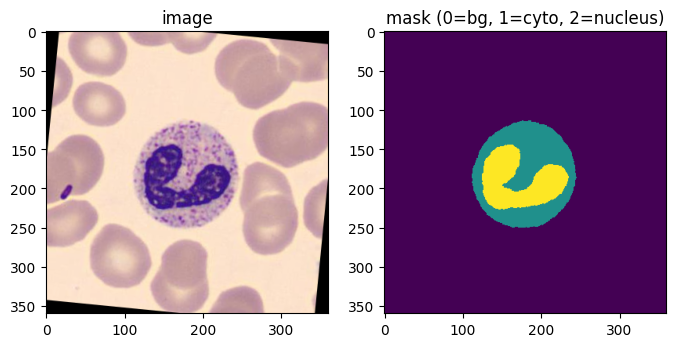

In [15]:
import matplotlib.pyplot as plt

image, mask = train_dataset[0]
image_np = image.permute(1, 2, 0).numpy()
image_np = image_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
image_np = np.clip(image_np, 0, 1)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(image_np)
ax[0].set_title("image")
ax[1].imshow(mask, cmap="viridis", vmin=0, vmax=2)
ax[1].set_title("mask (0=bg, 1=cyto, 2=nucleus)")
plt.show()

**Section 2 - Model**

In [16]:
#Ratio Feedback Gate
import torch
import torch.nn as nn
import torch.nn.functional as F
import segmentation_models_pytorch as smp

class RatioFeedbackGate(nn.Module):
    def __init__(self, channels, hidden=8, epsilon=1e-6):
        super().__init__()
        self.epsilon = epsilon
        self.probe_head = nn.Conv2d(channels, 3, kernel_size=1)
        self.mlp = nn.Sequential(
            nn.Linear(1, hidden),
            nn.ReLU(),
            nn.Linear(hidden, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        probe = self.probe_head(x)
        probe = F.softmax(probe, dim=1)

        cyto = probe[:, 1, :, :]
        nuc = probe[:, 2, :, :]

        nuc_area = nuc.sum(dim=[1, 2])
        cyto_area = cyto.sum(dim=[1, 2])
        ratio = torch.log((nuc_area + self.epsilon) / (cyto_area + self.epsilon))

        gate = self.mlp(ratio.unsqueeze(1))
        gate = gate.view(gate.size(0), gate.size(1), 1, 1)

        out = x + x * gate
        return out


class SegModel(nn.Module):
    def __init__(self, backbone, num_classes=3, use_rfg=True):
        super().__init__()

        if backbone == "attention_unet":
            base = smp.Unet(encoder_name="resnet34", encoder_weights="imagenet",
                             decoder_attention_type="scse", in_channels=3, classes=num_classes)
        elif backbone == "unet":
            base = smp.Unet(encoder_name="resnet34", encoder_weights="imagenet",
                             in_channels=3, classes=num_classes)

        self.encoder = base.encoder
        self.decoder = base.decoder
        self.seg_head = base.segmentation_head
        self.use_rfg = use_rfg

        if use_rfg:
            channels = self.seg_head[0].in_channels
            self.rfg = RatioFeedbackGate(channels)

    def forward(self, x):
        features = self.encoder(x)
        d = self.decoder(features)
        if self.use_rfg:
            d = self.rfg(d)
        out = self.seg_head(d)
        return out


def make_model(backbone, num_classes=3, use_rfg=True):
    return SegModel(backbone, num_classes, use_rfg)

In [17]:
for backbone in ["attention_unet", "unet"]:
    for use_rfg in [True, False]:
        model = make_model(backbone, num_classes=3, use_rfg=use_rfg)
        model = model.to(device)

        dummy_input = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(device)
        output = model(dummy_input)

        n_params = sum(p.numel() for p in model.parameters())
        print(f"{backbone:15s} use_rfg={str(use_rfg):5s} output={tuple(output.shape)} params={n_params:,}")


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

attention_unet  use_rfg=True  output=(2, 3, 360, 360) params=24,550,861
attention_unet  use_rfg=False output=(2, 3, 360, 360) params=24,550,650
unet            use_rfg=True  output=(2, 3, 360, 360) params=24,436,870
unet            use_rfg=False output=(2, 3, 360, 360) params=24,436,659


In [18]:
model = make_model("attention_unet", num_classes=3, use_rfg=True)
model = model.to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model ready on {device}")
print(f"Total parameters: {n_params:,}")

Model ready on cuda
Total parameters: 24,550,861


**Section 3 - Loss**

In [19]:
#3.1 — Dice + Focal (standard segmentation losses)

class DiceLoss(nn.Module):
    def __init__(self, epsilon=1e-6):
        super().__init__()
        self.epsilon = epsilon

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        num_classes = probs.shape[1]
        targets_onehot = F.one_hot(targets, num_classes).permute(0, 3, 1, 2).float()

        dims = (0, 2, 3)
        intersection = torch.sum(probs * targets_onehot, dims)
        union = torch.sum(probs + targets_onehot, dims)

        dice_per_class = (2 * intersection + self.epsilon) / (union + self.epsilon)
        return 1 - dice_per_class.mean()


class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

In [20]:
#3.2 — Ratio-consistency loss

class RatioConsistencyLoss(nn.Module):
    def __init__(self, epsilon=1e-6):
        super().__init__()
        self.epsilon = epsilon
        self.huber = nn.HuberLoss()

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)

        pred_nuc = probs[:, 2, :, :].sum(dim=[1, 2])
        pred_cyto = probs[:, 1, :, :].sum(dim=[1, 2])
        pred_ratio = torch.log((pred_nuc + self.epsilon) / (pred_cyto + self.epsilon))

        true_nuc = (targets == 2).float().sum(dim=[1, 2])
        true_cyto = (targets == 1).float().sum(dim=[1, 2])
        true_ratio = torch.log((true_nuc + self.epsilon) / (true_cyto + self.epsilon))

        return self.huber(pred_ratio, true_ratio)

In [21]:
#3.3 — Combined total loss

class TotalLoss(nn.Module):
    def __init__(self, lambda1=0.5, lambda2=0.3):
        super().__init__()
        self.dice = DiceLoss()
        self.focal = FocalLoss()
        self.ratio = RatioConsistencyLoss()
        self.lambda1 = lambda1
        self.lambda2 = lambda2

    def forward(self, logits, targets):
        dice_loss = self.dice(logits, targets)
        focal_loss = self.focal(logits, targets)
        loss = dice_loss + self.lambda1 * focal_loss

        if self.lambda2 > 0:
            ratio_loss = self.ratio(logits, targets)
            loss = loss + self.lambda2 * ratio_loss

        return loss

In [22]:
# Build dummy targets where nucleus is much smaller than cytoplasm
dummy_targets_imbalanced = torch.zeros(2, 360, 360, dtype=torch.long)
dummy_targets_imbalanced[:, 100:260, 100:260] = 1   # big cytoplasm region
dummy_targets_imbalanced[:, 160:200, 160:200] = 2   # small nucleus region
dummy_targets_imbalanced = dummy_targets_imbalanced.to(device)

# predicted logits that get the ratio WRONG (predict too much nucleus)
dummy_logits_bad = torch.zeros(2, 3, 360, 360).to(device)
dummy_logits_bad[:, 2, 100:260, 100:260] = 5.0   # predicts nucleus everywhere cytoplasm should be
dummy_logits_bad[:, 0, :, :] = -5.0

loss_with_ratio = TotalLoss(lambda1=0.5, lambda2=0.3).to(device)
loss_without_ratio = TotalLoss(lambda1=0.5, lambda2=0).to(device)

print("With ratio term:", loss_with_ratio(dummy_logits_bad, dummy_targets_imbalanced).item())
print("Without ratio term:", loss_without_ratio(dummy_logits_bad, dummy_targets_imbalanced).item())

With ratio term: 4.491828918457031
Without ratio term: 3.7106425762176514


**Section 4 - Training Infrastructure**

In [23]:
#4.1 — Metrics (Dice score, N:C ratio error)

def dice_score(logits, targets, num_classes=3, epsilon=1e-6):
    preds = torch.argmax(logits, dim=1)
    dice_per_class = []
    for c in range(num_classes):
        pred_c = (preds == c).float()
        target_c = (targets == c).float()
        intersection = (pred_c * target_c).sum()
        union = pred_c.sum() + target_c.sum()
        dice = (2 * intersection + epsilon) / (union + epsilon)
        dice_per_class.append(dice.item())
    return sum(dice_per_class) / num_classes


def nc_ratio_error(logits, targets, epsilon=1e-6):
    preds = torch.argmax(logits, dim=1)

    pred_nuc = (preds == 2).float().sum(dim=[1, 2])
    pred_cyto = (preds == 1).float().sum(dim=[1, 2])
    pred_ratio = pred_nuc / (pred_cyto + epsilon)

    true_nuc = (targets == 2).float().sum(dim=[1, 2])
    true_cyto = (targets == 1).float().sum(dim=[1, 2])
    true_ratio = true_nuc / (true_cyto + epsilon)

    error = torch.abs(pred_ratio - true_ratio)
    return error.mean().item()

In [24]:
#4.2 — Evaluation helper (runs on val/test set, no gradients)

def evaluate(model, loader, loss_fn):
    model.eval()
    total_loss = 0
    total_dice = 0
    total_ratio_error = 0
    n_batches = 0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)
            loss = loss_fn(logits, masks)

            total_loss += loss.item()
            total_dice += dice_score(logits, masks)
            total_ratio_error += nc_ratio_error(logits, masks)
            n_batches += 1

    return total_loss / n_batches, total_dice / n_batches, total_ratio_error / n_batches

In [25]:
def run_experiment(backbone, use_rfg, use_ratio_loss, seed, max_epochs=50, patience=8):
    torch.manual_seed(seed)
    run_name = f"{backbone}_rfg{int(use_rfg)}_ratio{int(use_ratio_loss)}_seed{seed}"
    checkpoint_path = os.path.join(CHECKPOINT_DIR, run_name + ".pt")
    state_path = os.path.join(CHECKPOINT_DIR, run_name + "_state.pt")

    model = make_model(backbone, num_classes=3, use_rfg=use_rfg).to(device)
    lambda2 = 0.3 if use_ratio_loss else 0
    loss_fn = TotalLoss(lambda1=0.5, lambda2=lambda2).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)

    start_epoch = 0
    best_dice = 0
    best_ratio_error = float("inf")
    epochs_no_improve = 0
    history = []

    if os.path.exists(state_path):
        state = torch.load(state_path, map_location=device)
        model.load_state_dict(state["model"])
        optimizer.load_state_dict(state["optimizer"])
        scheduler.load_state_dict(state["scheduler"])
        start_epoch = state["epoch"]
        best_dice = state["best_dice"]
        best_ratio_error = state["best_ratio_error"]
        epochs_no_improve = state["epochs_no_improve"]
        history = state["history"]
        print("Resuming", run_name, "from epoch", start_epoch)
    else:
        print("Starting run:", run_name)

    for epoch in range(start_epoch, max_epochs):
        model.train()
        train_loss, n_batches = 0, 0
        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)
            optimizer.zero_grad()
            logits = model(images)
            loss = loss_fn(logits, masks)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            n_batches += 1
        train_loss /= n_batches
        scheduler.step()

        val_loss, val_dice, val_ratio_error = evaluate(model, val_loader, loss_fn)
        print(f"Epoch {epoch+1}: train_loss={train_loss:.4f} val_loss={val_loss:.4f} val_dice={val_dice:.4f} val_ratio_error={val_ratio_error:.4f}")

        history.append({"epoch": epoch + 1, "train_loss": train_loss, "val_loss": val_loss,
                         "val_dice": val_dice, "val_ratio_error": val_ratio_error})

        is_better = (val_dice > best_dice) or (val_dice == best_dice and val_ratio_error < best_ratio_error)
        if is_better:
            best_dice, best_ratio_error, epochs_no_improve = val_dice, val_ratio_error, 0
            torch.save(model.state_dict(), checkpoint_path)
        else:
            epochs_no_improve += 1

        # save resume point every epoch — this is what survives an interrupt
        torch.save({"model": model.state_dict(), "optimizer": optimizer.state_dict(),
                    "scheduler": scheduler.state_dict(), "epoch": epoch + 1,
                    "best_dice": best_dice, "best_ratio_error": best_ratio_error,
                    "epochs_no_improve": epochs_no_improve, "history": history}, state_path)

        if epochs_no_improve >= patience:
            print("Early stopping at epoch", epoch + 1)
            break

    history_df = pd.DataFrame(history)
    history_path = os.path.join(LOG_DIR, run_name + "_history.csv")
    history_df.to_csv(history_path, index=False)

    if os.path.exists(state_path):
        os.remove(state_path)

    print("Run finished:", run_name)
    print("Best val dice:", best_dice, "Best val ratio error:", best_ratio_error)

    return {"run_name": run_name, "best_dice": best_dice, "best_ratio_error": best_ratio_error,
            "checkpoint_path": checkpoint_path, "history_path": history_path}

In [ ]:
import time
t0 = time.time()

result = run_experiment("attention_unet", use_rfg=False, use_ratio_loss=False, seed=0, max_epochs=20, patience=4)

print("Total time for this run:", (time.time() - t0) / 60, "minutes")
print(result)

Starting run: attention_unet_rfg0_ratio0_seed0
Epoch 1: train_loss=0.1141 val_loss=0.0315 val_dice=0.9819 val_ratio_error=0.0933
Epoch 2: train_loss=0.0314 val_loss=0.0259 val_dice=0.9834 val_ratio_error=0.0939
Epoch 3: train_loss=0.0259 val_loss=0.0225 val_dice=0.9852 val_ratio_error=0.0985
Epoch 4: train_loss=0.0227 val_loss=0.0206 val_dice=0.9868 val_ratio_error=0.0760
Epoch 5: train_loss=0.0236 val_loss=0.0191 val_dice=0.9875 val_ratio_error=0.0768
Epoch 6: train_loss=0.0206 val_loss=0.0184 val_dice=0.9877 val_ratio_error=0.0814
Epoch 7: train_loss=0.0209 val_loss=0.0182 val_dice=0.9879 val_ratio_error=0.0710
Epoch 8: train_loss=0.0195 val_loss=0.0169 val_dice=0.9888 val_ratio_error=0.0602
Epoch 9: train_loss=0.0189 val_loss=0.0165 val_dice=0.9891 val_ratio_error=0.0610
Epoch 10: train_loss=0.0186 val_loss=0.0161 val_dice=0.9893 val_ratio_error=0.0633
Epoch 11: train_loss=0.0182 val_loss=0.0161 val_dice=0.9894 val_ratio_error=0.0676
Epoch 12: train_loss=0.0178 val_loss=0.0159 val_d

**Section 5 — Run the ablation grid**

In [26]:
configs = []

# Backbone A: Attention U-Net, full 4-way ablation, 3 seeds
for seed in [0, 1, 2]:
    configs.append({"backbone": "attention_unet", "use_rfg": False, "use_ratio_loss": False, "seed": seed})  # baseline
    configs.append({"backbone": "attention_unet", "use_rfg": False, "use_ratio_loss": True,  "seed": seed})  # loss alone
    configs.append({"backbone": "attention_unet", "use_rfg": True,  "use_ratio_loss": False, "seed": seed})  # module alone
    configs.append({"backbone": "attention_unet", "use_rfg": True,  "use_ratio_loss": True,  "seed": seed})  # full proposed method

# Backbone B: plain U-Net, module on/off only, ratio loss always on, 3 seeds
for seed in [0, 1, 2]:
    configs.append({"backbone": "unet", "use_rfg": False, "use_ratio_loss": True, "seed": seed})
    configs.append({"backbone": "unet", "use_rfg": True,  "use_ratio_loss": True, "seed": seed})

print("Total configs:", len(configs))

Total configs: 18


In [ ]:
RESULTS_PATH = os.path.join(LOG_DIR, "all_results.csv")

if os.path.exists(RESULTS_PATH):
    results_df = pd.read_csv(RESULTS_PATH)
    completed_runs = set(results_df["run_name"])
else:
    results_df = pd.DataFrame()
    completed_runs = set()

print("Already completed runs:", len(completed_runs))

for cfg in configs:
    run_name = f"{cfg['backbone']}_rfg{int(cfg['use_rfg'])}_ratio{int(cfg['use_ratio_loss'])}_seed{cfg['seed']}"

    if run_name in completed_runs:
        print("Skipping already-completed run:", run_name)
        continue

    result = run_experiment(
        backbone=cfg["backbone"],
        use_rfg=cfg["use_rfg"],
        use_ratio_loss=cfg["use_ratio_loss"],
        seed=cfg["seed"],
        max_epochs=50,
        patience=8,
    )

    results_df = pd.concat([results_df, pd.DataFrame([result])], ignore_index=True)
    results_df.to_csv(RESULTS_PATH, index=False)

print("All configs done.")
print(results_df)

**Section 6 — Results**

In [ ]:
RESULTS_PATH = os.path.join(LOG_DIR, "all_results.csv")
results_df = pd.read_csv(RESULTS_PATH)

table = results_df.groupby(["backbone", "use_rfg", "use_ratio_loss"]).agg(
    dice_mean=("best_dice", "mean"),
    dice_std=("best_dice", "std"),
    ratio_err_mean=("best_ratio_error", "mean"),
    ratio_err_std=("best_ratio_error", "std"),
    n_seeds=("seed", "count"),
).reset_index()

table["Dice"] = table["dice_mean"].round(4).astype(str) + " ± " + table["dice_std"].round(4).astype(str)
table["N:C Ratio Error"] = table["ratio_err_mean"].round(4).astype(str) + " ± " + table["ratio_err_std"].round(4).astype(str)

print(table[["backbone", "use_rfg", "use_ratio_loss", "n_seeds", "Dice", "N:C Ratio Error"]].to_string(index=False))

table.to_csv(os.path.join(LOG_DIR, "ablation_table.csv"), index=False)

In [ ]:
def load_history(run_name):
    return pd.read_csv(os.path.join(LOG_DIR, run_name + "_history.csv"))

hist_with_ratio = load_history("attention_unet_rfg1_ratio1_seed0")
hist_without_ratio = load_history("attention_unet_rfg1_ratio0_seed0")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(hist_with_ratio["epoch"], hist_with_ratio["val_dice"], label="with ratio loss")
axes[0].plot(hist_without_ratio["epoch"], hist_without_ratio["val_dice"], label="without ratio loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Validation Dice")
axes[0].legend(); axes[0].set_title("(a) Validation Dice")

axes[1].plot(hist_with_ratio["epoch"], hist_with_ratio["val_ratio_error"], label="with ratio loss")
axes[1].plot(hist_without_ratio["epoch"], hist_without_ratio["val_ratio_error"], label="without ratio loss")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("N:C Ratio Error")
axes[1].legend(); axes[1].set_title("(b) N:C Ratio Error")

plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, "fig3_training_curves.png"), dpi=300)
plt.show()

In [ ]:
best_run = "attention_unet_rfg1_ratio1_seed0"
best_model = make_model("attention_unet", num_classes=3, use_rfg=True).to(device)
best_model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, best_run + ".pt"), map_location=device))
best_model.eval()

images, masks = next(iter(val_loader))
images, masks = images.to(device), masks.to(device)

with torch.no_grad():
    logits = best_model(images)
    preds = torch.argmax(logits, dim=1)

fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for i in range(3):
    img_np = images[i].cpu().permute(1, 2, 0).numpy()
    img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_np = np.clip(img_np, 0, 1)

    axes[i, 0].imshow(img_np); axes[i, 0].set_title("Input"); axes[i, 0].axis("off")
    axes[i, 1].imshow(masks[i].cpu(), cmap="viridis", vmin=0, vmax=2); axes[i, 1].set_title("Expert Mask"); axes[i, 1].axis("off")
    axes[i, 2].imshow(preds[i].cpu(), cmap="viridis", vmin=0, vmax=2); axes[i, 2].set_title("Predicted Mask"); axes[i, 2].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, "fig4_example_predictions.png"), dpi=300)
plt.show()

## **PHASE 02**

In [ ]:
def segment_cell_color(image_rgb, erode_size=15):
    """
    image_rgb: HxWx3 uint8 RGB image
    Returns: HxW uint8 mask, 0=background, 1=cytoplasm, 2=nucleus
    """
    hsv = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2HSV)
    h, s, v = hsv[:, :, 0], hsv[:, :, 1], hsv[:, :, 2]

    cell_candidate = ((h > 100) & (h < 180) & (s > 35)).astype(np.uint8)

    # only remove tiny noise specks - do NOT close gaps, that bridges
    # touching-but-separate cells together
    noise_kernel = np.ones((3, 3), np.uint8)
    cell_candidate = cv2.morphologyEx(cell_candidate, cv2.MORPH_OPEN, noise_kernel)

    if cell_candidate.sum() == 0:
        return np.zeros(image_rgb.shape[:2], dtype=np.uint8)

    # erode hard enough to break thin touching-bridges between separate cells
    erode_kernel = np.ones((erode_size, erode_size), np.uint8)
    eroded = cv2.erode(cell_candidate, erode_kernel)

    n_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(eroded, connectivity=8)
    H, W = image_rgb.shape[:2]
    center = np.array([W / 2, H / 2])

    if n_labels <= 1:
        main_cell_mask = cell_candidate
    else:
        # pick whichever surviving blob is closest to image center - these AML
        # images are single-cell crops, so the real target cell is centered
        dists = [np.linalg.norm(centroids[i] - center) for i in range(1, n_labels)]
        seed_label = 1 + int(np.argmin(dists))
        seed_mask = (labels == seed_label).astype(np.uint8)

        # grow ONLY this isolated blob back to its full size - other blobs
        # were already discarded above, so they can't get pulled back in
        grown = cv2.dilate(seed_mask, erode_kernel)
        main_cell_mask = (grown & cell_candidate).astype(np.uint8)

    nucleus_mask = ((s > 100) & (v < 180)).astype(np.uint8) & main_cell_mask
    nucleus_mask = cv2.morphologyEx(nucleus_mask, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8))

    mask = np.zeros((H, W), dtype=np.uint8)
    mask[main_cell_mask == 1] = 1
    mask[nucleus_mask == 1] = 2
    return mask

In [ ]:
import random

random.seed(42)

blast_classes = ["MYO", "MOB", "PMO", "PMB", "MYB", "MMZ"]
control_classes = ["BAS", "EBO", "EOS", "KSC", "LYA", "LYT", "MON", "NGB", "NGS"]

def sample_class(class_name, n):
    class_dir = os.path.join(AML_DIR, class_name)
    files = [f for f in os.listdir(class_dir) if f.lower().endswith(".tiff")]
    n = min(n, len(files))  # in case a class has fewer than requested
    chosen = random.sample(files, n)
    return [{"class": class_name, "filename": f, "path": os.path.join(class_dir, f)} for f in chosen]

subset = []
for c in blast_classes:
    subset += sample_class(c, 45)
for c in control_classes:
    subset += sample_class(c, 20)

subset_df = pd.DataFrame(subset)
print("Total subset size:", len(subset_df))
print(subset_df["class"].value_counts())

subset_df.to_csv(os.path.join(LOG_DIR, "aml_subset_450.csv"), index=False)

In [ ]:
sample_path = subset_df.iloc[0]["path"]
print("Testing on:", sample_path)

image_bgr = cv2.imread(sample_path)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

mask = segment_cell_color(image_rgb)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(image_rgb)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(mask, cmap="viridis", vmin=0, vmax=2)
axes[1].set_title("Pseudo-label (0=bg, 1=cyto, 2=nucleus)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

unique, counts = np.unique(mask, return_counts=True)
print("Class pixel counts:", dict(zip(unique.tolist(), counts.tolist())))

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

sample_path = subset_df.iloc[0]["path"]
image_bgr = cv2.imread(sample_path)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

axes[0].imshow(image_rgb); axes[0].set_title("Original"); axes[0].axis("off")

for i, erode_size in enumerate([15, 25, 35]):
    mask = segment_cell_color(image_rgb, erode_size=erode_size)
    axes[i+1].imshow(mask, cmap="viridis", vmin=0, vmax=2)
    axes[i+1].set_title(f"erode_size={erode_size}")
    axes[i+1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
AML_MASK_DIR = os.path.join(DATA_DIR, "aml_pseudo_masks")
os.makedirs(AML_MASK_DIR, exist_ok=True)

failed = []

for idx, row in subset_df.iterrows():
    image_bgr = cv2.imread(row["path"])
    if image_bgr is None:
        failed.append(row["path"])
        continue

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    mask = segment_cell_color(image_rgb, erode_size=35)

    # flag suspiciously empty or suspiciously huge masks for manual review later
    cell_fraction = (mask > 0).mean()
    if cell_fraction < 0.02 or cell_fraction > 0.85:
        failed.append(row["path"])

    mask_filename = row["filename"].replace(".tiff", "_mask.png")
    cv2.imwrite(os.path.join(AML_MASK_DIR, mask_filename), mask)

    if idx % 50 == 0:
        print(f"Processed {idx}/{len(subset_df)}")

print("Done. Flagged as possibly bad:", len(failed))
print(failed[:10])

In [ ]:
sample_check = subset_df.sample(12, random_state=1)

fig, axes = plt.subplots(3, 8, figsize=(20, 8))
for i, (idx, row) in enumerate(sample_check.iterrows()):
    image_bgr = cv2.imread(row["path"])
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    mask_path = os.path.join(AML_MASK_DIR, row["filename"].replace(".tiff", "_mask.png"))
    mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)

    r = (i // 4) * 2
    c = (i % 4) * 2
    axes[r, c].imshow(image_rgb); axes[r, c].axis("off"); axes[r, c].set_title(row["class"], fontsize=9)
    axes[r, c+1].imshow(mask, cmap="viridis", vmin=0, vmax=2); axes[r, c+1].axis("off")

plt.tight_layout()
plt.show()

**Section 08 - Fine Tuning**

In [ ]:
from sklearn.model_selection import train_test_split

def safe_split(df, test_size, stratify_col, seed=42):
    try:
        return train_test_split(df, test_size=test_size, stratify=df[stratify_col], random_state=seed)
    except ValueError:
        print("Stratified split failed (some class too small) - falling back to plain random split")
        return train_test_split(df, test_size=test_size, random_state=seed)

train_df, temp_df = safe_split(subset_df, 0.3, "class")
val_df, test_df = safe_split(temp_df, 0.5, "class")
print("train:", len(train_df), "val:", len(val_df), "test:", len(test_df))

In [ ]:
class AMLDataset(Dataset):
    def __init__(self, df, mask_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.mask_dir = mask_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "path"]
        mask_filename = self.df.loc[idx, "filename"].replace(".tiff", "_mask.png")
        mask_path = os.path.join(self.mask_dir, mask_filename)

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        return image, mask.long()

In [ ]:
AML_IMG_SIZE = 256  # smaller than WBCAtt+'s 360 - AML images are cropped, this is fine

aml_train_aug = A.Compose([
    A.Resize(AML_IMG_SIZE, AML_IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.Rotate(limit=20, p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.3),
    A.Affine(translate_percent=0.1, scale=(0.9, 1.1), p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])
aml_val_aug = A.Compose([
    A.Resize(AML_IMG_SIZE, AML_IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

aml_train_ds = AMLDataset(train_df, AML_MASK_DIR, transform=aml_train_aug)
aml_val_ds = AMLDataset(val_df, AML_MASK_DIR, transform=aml_val_aug)
aml_test_ds = AMLDataset(test_df, AML_MASK_DIR, transform=aml_val_aug)

aml_train_loader = DataLoader(aml_train_ds, batch_size=8, shuffle=True)
aml_val_loader = DataLoader(aml_val_ds, batch_size=8, shuffle=False)
aml_test_loader = DataLoader(aml_test_ds, batch_size=8, shuffle=False)

print("AML train batches:", len(aml_train_loader))
print("AML val batches:", len(aml_val_loader))
print("AML test batches:", len(aml_test_loader))

In [ ]:
def fine_tune_on_aml(source_checkpoint_path, backbone, use_rfg, max_epochs=30, patience=6, lr=2.5e-5):
    model = make_model(backbone, num_classes=3, use_rfg=use_rfg).to(device)
    model.load_state_dict(torch.load(source_checkpoint_path, map_location=device))
    print("Loaded pretrained weights from:", source_checkpoint_path)

    run_name = f"aml_finetune_{backbone}_rfg{int(use_rfg)}"

    loss_fn = TotalLoss(lambda1=0.5, lambda2=0.3).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)

    best_dice, best_ratio_error, epochs_no_improve = 0, float("inf"), 0
    history = []
    checkpoint_path = os.path.join(CHECKPOINT_DIR, run_name + ".pt")

    for epoch in range(max_epochs):
        model.train()
        train_loss, n_batches = 0, 0
        for images, masks in aml_train_loader:
            images, masks = images.to(device), masks.to(device)
            optimizer.zero_grad()
            logits = model(images)
            loss = loss_fn(logits, masks)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            n_batches += 1
        train_loss /= n_batches
        scheduler.step()

        val_loss, val_dice, val_ratio_error = evaluate(model, aml_val_loader, loss_fn)
        print(f"Epoch {epoch+1}: train_loss={train_loss:.4f} val_dice={val_dice:.4f} val_ratio_error={val_ratio_error:.4f}")

        history.append({"epoch": epoch+1, "train_loss": train_loss, "val_loss": val_loss,
                         "val_dice": val_dice, "val_ratio_error": val_ratio_error})

        is_better = (val_dice > best_dice) or (val_dice == best_dice and val_ratio_error < best_ratio_error)
        if is_better:
            best_dice, best_ratio_error, epochs_no_improve = val_dice, val_ratio_error, 0
            torch.save(model.state_dict(), checkpoint_path)
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print("Early stopping at epoch", epoch + 1)
            break

    pd.DataFrame(history).to_csv(os.path.join(LOG_DIR, run_name + "_history.csv"), index=False)
    print("Fine-tuning finished. Best val dice:", best_dice, "Best val ratio error:", best_ratio_error)
    return {"run_name": run_name, "best_dice": best_dice, "best_ratio_error": best_ratio_error, "checkpoint_path": checkpoint_path}

In [ ]:
best_phase1_checkpoint = os.path.join(CHECKPOINT_DIR, "attention_unet_rfg1_ratio1_seed0.pt")  # adjust to your actual best run

result = fine_tune_on_aml(best_phase1_checkpoint, backbone="attention_unet", use_rfg=True)
print(result)